# Bootstrap 

Статья: https://habr.com/ru/companies/X5Tech/articles/679842/

В Bootstrap мы рассматриваем какое-то одно распределение и далее много раз сэмплируем его, чтобы сделать оценку параметров

**С помощью Bootstrap можно строить доверительные интервалы!**

Например, можно строить доверительные интервалы для наших нетривиальных оценок параметров   
Допустим, если оцениваем 0.9 квантиль распределния, то даже на большой выборке не выполнена ЦПТ     
Поэтому можем много раз сэмплировать данные из выборки и считать нашу оценку    
Так получим примерное распределение оценки

**С помощью Bootstrap можно оценивать гипотезы!**

Например, что если мы оцениваем квантиль распределния.   
Мы не можем просто применить ttest, так как не выполнена ЦПТ    
Но можно с помощью Bootstrap построить доверительный интервал для нашей оценки  
И посмотреть, лежит ли в нем 0  

О чем помнить 

1. Bootstrap может быть долгим
2. Если данные в выборке как-то зависимы друг от друга, то для генерации подвыборок важно это учитывать

In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import random

plt.rcParams['figure.dpi'] = 150

plt.style.use('default')

plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

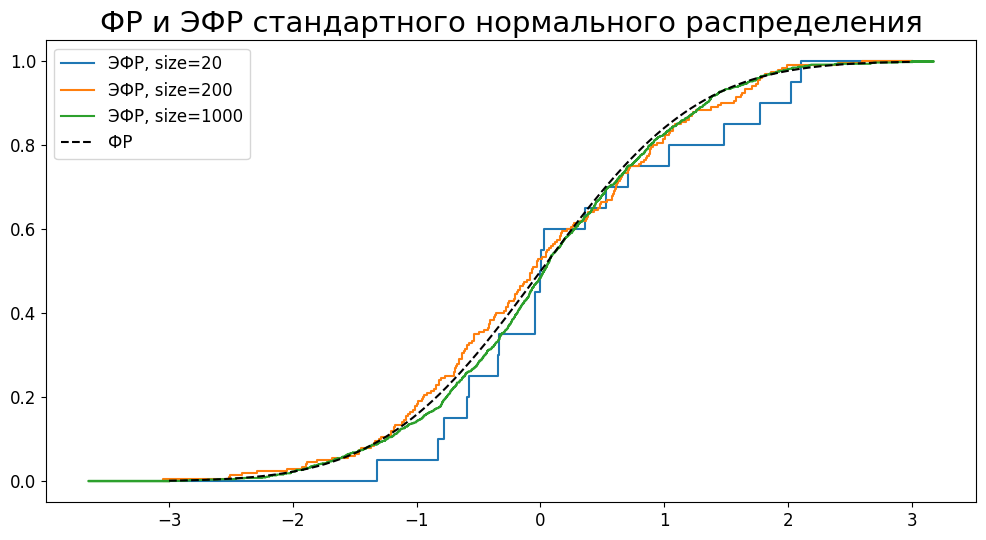

In [ ]:
# Покажем, как работает эмпирическая функция распределения

plt.figure(figsize=(12, 6))

def plot_ecdf(values, label, xlim):
    """Построить график ЭФР."""
    X_ = sorted(set(values))
    Y_ = [np.mean(values <= x) for x in X_]
    X = [xlim[0]] + sum([[v, v] for v in X_], []) + [xlim[1]]
    Y = [0, 0] + sum([[v, v] for v in Y_], [])
    plt.plot(X, Y, label=label)

# Генерируем данные и строим ЭФР
for size in [20, 200, 1000]:
    values = np.random.normal(size=size)
    plot_ecdf(values, f'ЭФР, size={size}', [-3, 3])

# Строим ФР
X = np.linspace(-3, 3, 1000)
Y = stats.norm.cdf(X)
plt.plot(X, Y, '--', color='k', label='ФР')
plt.title('ФР и ЭФР стандартного нормального распределения')
plt.legend()
plt.show()

Estimate of 90% quantile: 115.370
Var of 90% quantile is 2.117


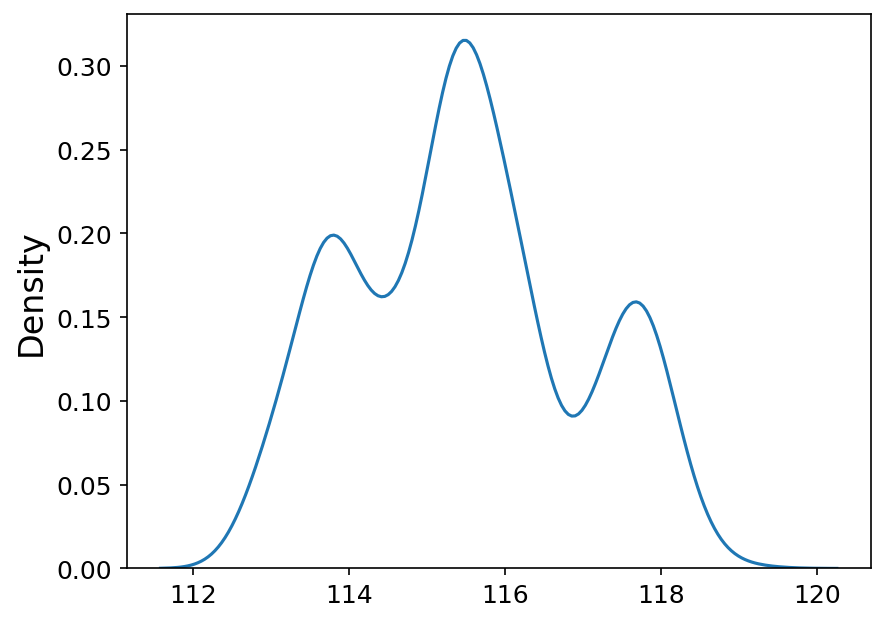

In [18]:
# Сделаем Bootstrap, чтобы оценить стандартное отклонение 90% квантиля 

plt.rcParams['figure.dpi'] = 150

sample_size = 1000
sample = stats.norm(loc=90, scale=20).rvs(sample_size)
quantile = np.quantile(sample, 0.9)

bootstrap_quantiles = []
n_iter = 1000
for _ in range(n_iter):
    bootstrap_sample = np.random.choice(sample, size=sample_size, replace=True)
    bootstrap_quantile = np.quantile(bootstrap_sample, 0.9)

    bootstrap_quantiles.append(bootstrap_quantile)

sns.kdeplot(bootstrap_quantiles)

bootstrap_quantiles = np.array(bootstrap_quantiles)

var = bootstrap_quantiles.var()
print(f"Estimate of 90% quantile: {quantile:.3f}")
print(f"Var of 90% quantile is {var:.3f}")

<Axes: ylabel='Density'>

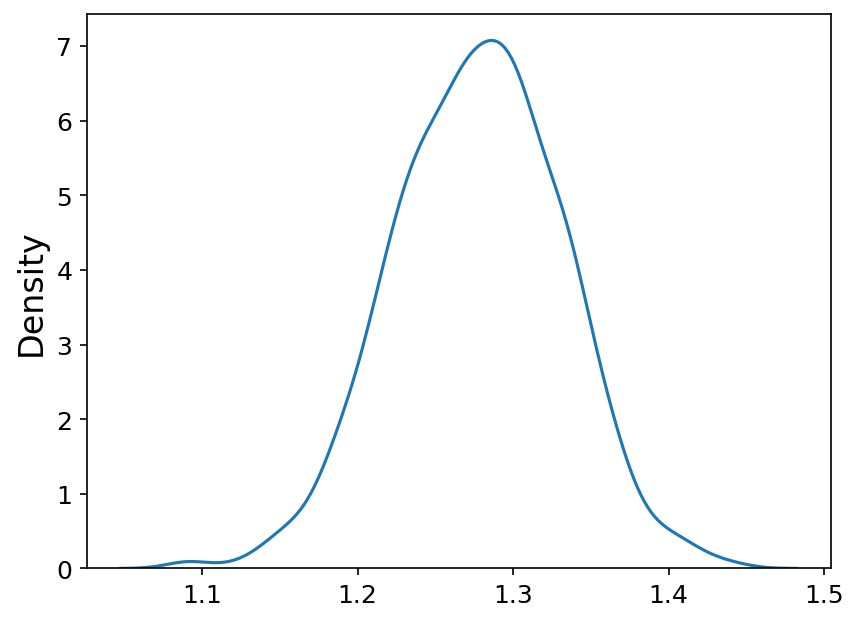

In [ ]:
# Правда ли, что 90% квантиль нормального распрелеления сама распределена нормально? 
# Кажется, что да!

quantiles = []
n_iter = 1000

for _ in range(n_iter):
    quantile = np.quantile(stats.norm().rvs(1000), 0.9)

    quantiles.append(quantile)

quantiles = np.array(quantiles)

sns.kdeplot(quantiles)

In [37]:
# Строим доверительные интервалы с помощью Bootstrap 3-мя способами 

# Тут мы предполагаем, что наша статистика estimated_value
# имеет нормальное распределение
# Например, для выборочного среднего это верно по ЦПТ
def get_normal_ci(bootstrap_stats, estimated_value, alpha):
    t = stats.norm().ppf(1 - alpha / 2)

    se = np.sqrt(bootstrap_stats.var())

    ci_left = estimated_value - t * se
    ci_right = estimated_value + t * se

    return (ci_left, ci_right)

# Тут мы просто смотрим на распределение, полученное после Bootstrap 
# И считаем CI для него
# Estimated value даже не используем
def get_percentile_ci(bootstrap_stats, estimated_value, alpha):
    ci_left, ci_right = np.quantile(bootstrap_stats, [alpha / 2, 1 - alpha / 2])
    return ci_left, ci_right

# Тут мы смотрим на разницу оценки параметра и ее значения (q_est - q_true)
# Предполагаем, что распределение этой разницы в мире Bootstrap
# такое же, как в реальности 
#
def get_pivotal_ci(bootstrap_stats, estimated_value, alpha):
    ci_left, ci_right = 2 * estimated_value - np.quantile(bootstrap_stats, [1 - alpha / 2, alpha / 2])
    return ci_left, ci_right

### **Pivotal Confidence Interval (Basic Bootstrap)**

**Идея:** Мы предполагаем, что распределение ошибки в реальности $(\hat{\theta} - \theta)$ такое же, как в бутстрап-мире $(\hat{\theta}^* - \hat{\theta})$

Тут внимательно!  

То есть если оценка $\hat{\theta}$ меньше истинного значения $\theta$, то мы будем считать, что та же оценка в Bootstrap мире $\hat{\theta}^*$ будет меньше нашей исходной оценки $\hat{\theta}$      

То есть как бы в Bootstrap мире мы считаем,     
что наше истинное значение параметра это $\hat{\theta}$.    
И характер ошибки в Bootstrap мире сохранится.   
И в целом это логично.     
Получается, что мы корректируем истинные границы нашего параметра 

   $$Q_{\alpha/2}^* \le \hat{\theta} - \theta \le Q_{1-\alpha/2}^*$$

   $$\hat{\theta} - Q_{1-\alpha/2}^* \le \theta \le \hat{\theta} - Q_{\alpha/2}^*$$

   Так как $Q^*(\hat{\theta}^* - \hat{\theta}) = \text{Quantile}(\hat{\theta}^*) - \hat{\theta}$, получаем:
   $$CI = [ \hat{\theta} - (\text{Quantile}_{1-\alpha/2}(\hat{\theta}^*) - \hat{\theta}), \quad \hat{\theta} - (\text{Quantile}_{\alpha/2}(\hat{\theta}^*) - \hat{\theta}) ]$$

   $$\mathbf{CI = [ 2\hat{\theta} - \text{Quantile}_{1-\alpha/2}(\hat{\theta}^*), \quad 2\hat{\theta} - \text{Quantile}_{\alpha/2}(\hat{\theta}^*) ]}$$

**Суть:** Если бутстрап-распределение смещено вправо (переоценка), формула «отзеркалит» его влево, корректируя смещение.


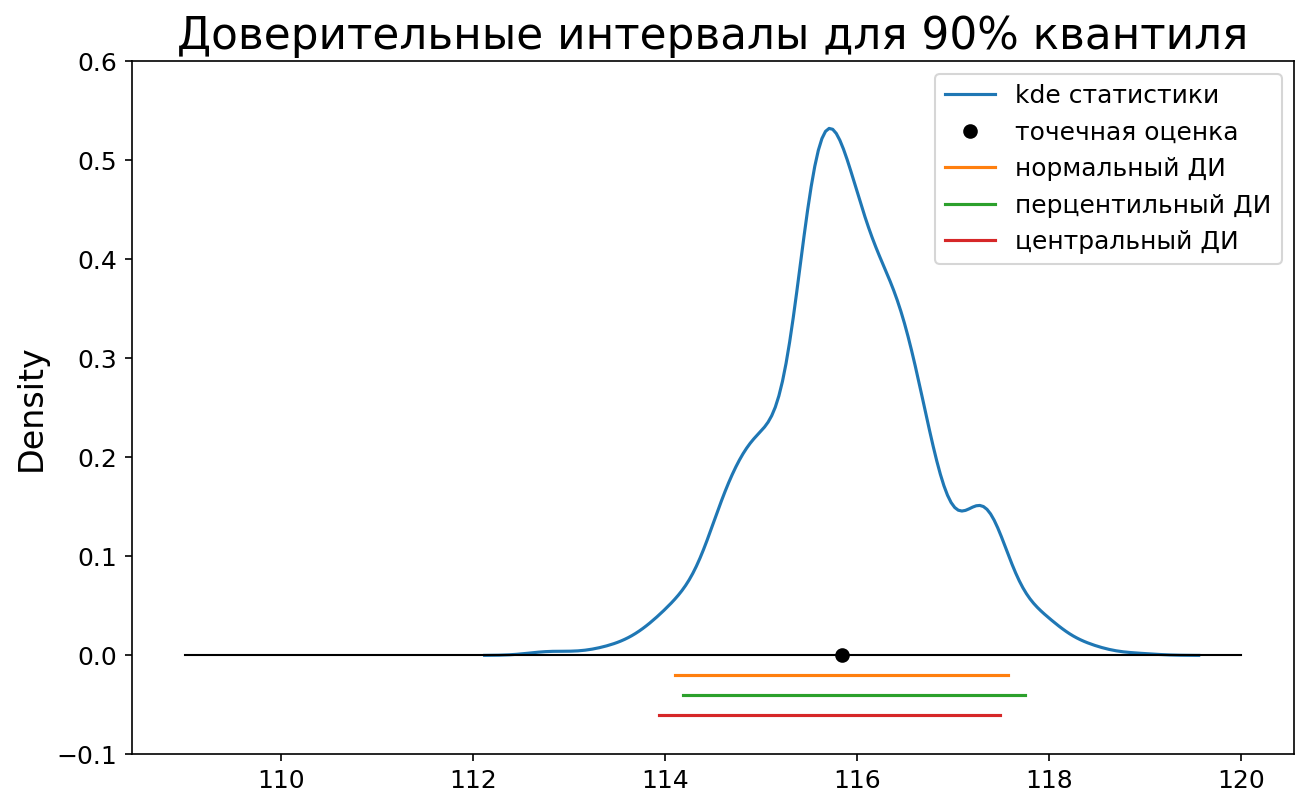

In [38]:
# Посмотрим на 3 наших доверительных интервала

plt.rcParams['figure.dpi'] = 150

sample_size = 1000
alpha = 0.05

# Выборка, которая у нас есть
sample = stats.norm(loc=90, scale=20).rvs(sample_size)

# Оценка параметра по нашему распределению
quantile = np.quantile(sample, 0.9)

# Делаем Bootstrap
n_iter = 1000
bootstrap_quantiles = np.quantile(np.random.choice(sample, (n_iter, sample_size), replace=True), 0.9, axis=1)

normal_ci = get_normal_ci(bootstrap_quantiles, quantile, alpha)
percentile_ci = get_percentile_ci(bootstrap_quantiles, quantile, alpha)
pivotal_ci = get_pivotal_ci(bootstrap_quantiles, quantile, alpha)

plt.figure(figsize=(10, 6))

sns.kdeplot(bootstrap_quantiles, label='kde статистики')
plt.plot([quantile], [0], 'o', c='k', markersize=6, label='точечная оценка')
plt.plot([109, 120], [0, 0], 'k', linewidth=1)
d = 0.02
plt.plot(normal_ci, [-d, -d], label='нормальный ДИ')
plt.plot(percentile_ci, [-d*2, -d*2], label='перцентильный ДИ')
plt.plot(pivotal_ci, [-d*3, -d*3], label='центральный ДИ')

plt.ylim(-0.1, 0.6)
plt.title('Доверительные интервалы для 90% квантиля')
plt.legend(loc='upper right')
plt.show()


**С помощью Bootstrap можно оценивать гипотезы!**

Например, что если мы оцениваем квантиль распределния.   
Мы не можем просто применить ttest, так как не выполнена ЦПТ    
Но можно с помощью Bootstrap построить доверительный интервал для нашей оценки  
И посмотреть, лежит ли в нем 0  

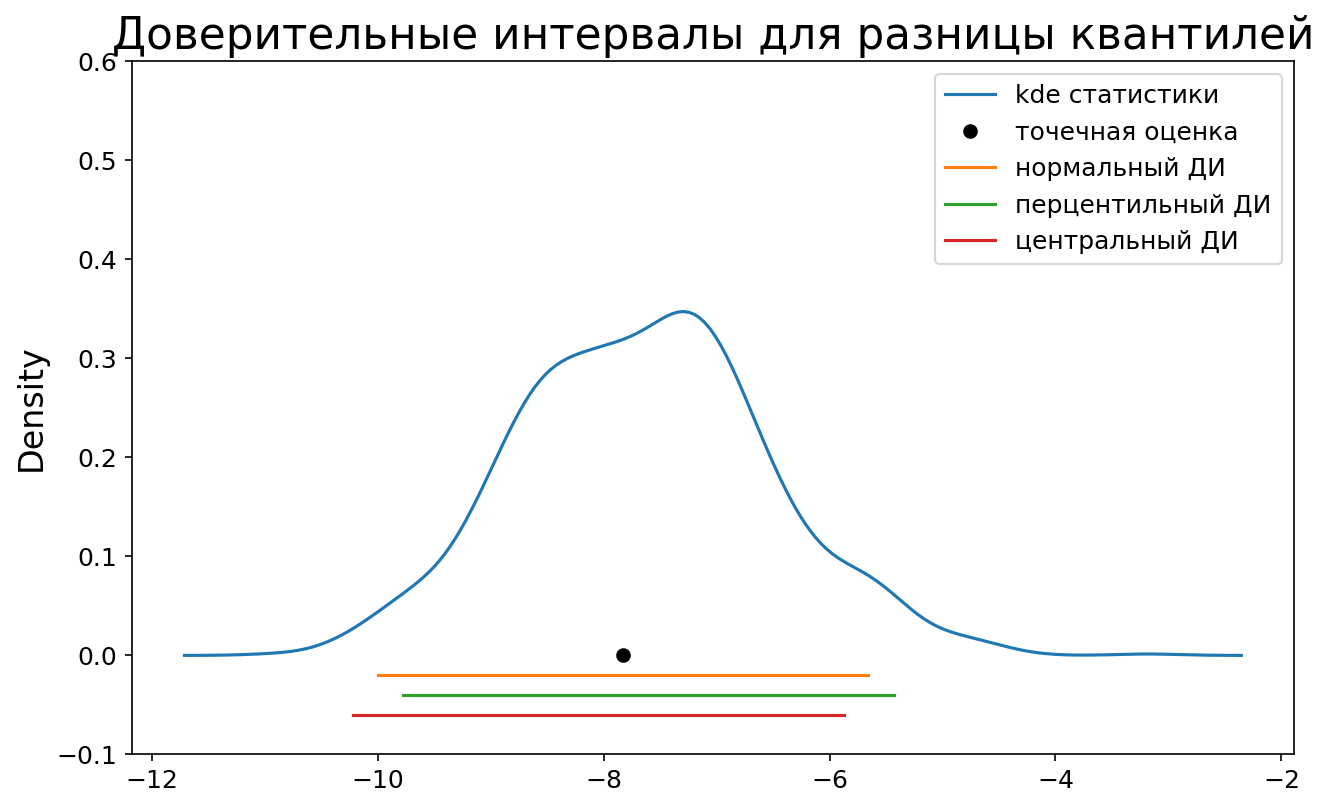

Оценка 90% квантиля изменилась на -7.8
Pivotal CI = [-10.2, -5.9]
Отличия статистически значимые? Yes


In [40]:
# Реализуем это!

plt.rcParams['figure.dpi'] = 150

sample_size = 1000
alpha = 0.05

# Контрольная и тестовая выборки
# В тесте уменьшили дисперсию => квантиль уменьшилась
control = stats.norm(loc=90, scale=20).rvs(sample_size)
test = stats.norm(loc=90, scale=15).rvs(sample_size) 

# Оценка разности
pe = np.quantile(test, 0.9) - np.quantile(control, 0.9)


# Делаем Bootstrap
n_iter = 1000
bootstrap_control = np.quantile(np.random.choice(control, (n_iter, sample_size), replace=True), 0.9, axis=1)
bootstrap_test = np.quantile(np.random.choice(test, (n_iter, sample_size), replace=True), 0.9, axis=1)
bootstrap_pe = bootstrap_test - bootstrap_control

normal_ci = get_normal_ci(bootstrap_pe, pe, alpha)
percentile_ci = get_percentile_ci(bootstrap_pe, pe, alpha)
pivotal_ci = get_pivotal_ci(bootstrap_pe, pe, alpha)

plt.figure(figsize=(10, 6))

sns.kdeplot(bootstrap_pe, label='kde статистики')
plt.plot([pe], [0], 'o', c='k', markersize=6, label='точечная оценка')
d = 0.02
plt.plot(normal_ci, [-d, -d], label='нормальный ДИ')
plt.plot(percentile_ci, [-d*2, -d*2], label='перцентильный ДИ')
plt.plot(pivotal_ci, [-d*3, -d*3], label='центральный ДИ')

plt.ylim(-0.1, 0.6)
plt.title('Доверительные интервалы для разницы квантилей')
plt.legend(loc='upper right')
plt.show()

print(f"Оценка 90% квантиля изменилась на {pe:.1f}")
print(f"Pivotal CI = [{pivotal_ci[0]:.1f}, {pivotal_ci[1]:.1f}]")
print(f"Отличия статистически значимые? {'No' if pivotal_ci[0] < 0 < pivotal_ci[1] else 'Yes'}")
